In [1]:
%cd ..

/scratch/big/home/daawic/BSc-Thesis


In [11]:
import os
import torch
import matplotlib.pyplot as plt
import torchvision.transforms as transforms 
from project.models import EDMCallum
from project.util.data import ReplayMemoryData

In [ ]:
CHECKPOINT = os.path.join("..", "checkpoints", "diff", "SpaceInvaders.pt")
DATA = os.path.join("..", "checkpoints", "memory", "SpaceInvaders.pt")

In [14]:
device = "cuda:1"

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Pad(2),
    transforms.Normalize(0.5, 0.5),
])

In [5]:
data = ReplayMemoryData(
    memory=DATA,
    transform=transform,
    cap=500000,
    train=False
)

In [20]:
model = EDMCallum.from_checkpoint(CHECKPOINT, device=device, U=20).to(device)

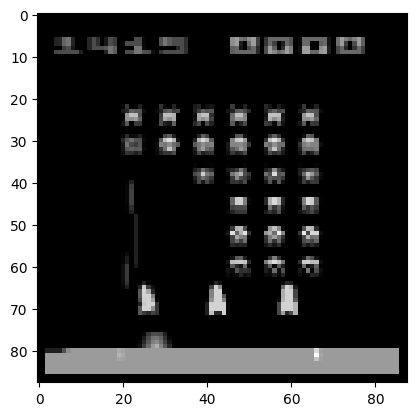

In [38]:
sample = data[2112].unsqueeze(0)
plt.imshow(sample.mean((0, 1)),  cmap="grey")

In [52]:
mask = torch.ones_like(sample)
mask[:, :, 22:66, 11:60] = 0

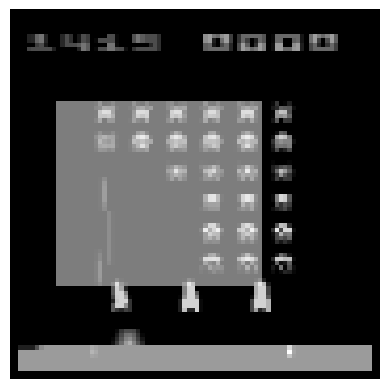

In [70]:
plt.imshow(((1 - (0.5 * (1 - mask))) * sample).squeeze().mean(0), cmap="grey")
plt.axis("off")
plt.savefig("../results/inpainting/example_masked.svg")

In [60]:
inpainted = model.inpaint(sample.to(device), mask.to(device))

100%|██████████| 32/32 [00:32<00:00,  1.02s/it]


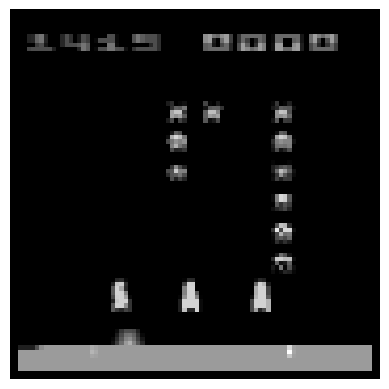

In [72]:
plt.imshow(inpainted.cpu().squeeze().mean((0)), cmap="grey")
plt.axis("off")
plt.savefig("../results/inpainting/example_inpainted.svg")